In [1]:
import xgboost as xgb

# === Core ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt

# === Model Selection & Evaluation ===
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

# === Tree-Based Model ===
from sklearn.ensemble import RandomForestRegressor

# === Utility ===
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display


C:\Users\ckshr\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [15]:
url = '../data/housing_data_with_clustered_neigh.csv'
housing_binary_xg = pd.read_csv(url)


In [16]:
housing_binary_xg['log_latestPrice'] = np.log(housing_binary_xg['latestPrice'])
housing_binary_xg = housing_binary_xg.drop(columns=['lotSizeSqFt', 'livingAreaSqFt','avgSchoolRating', 'avgSchoolSize', 'yearsOld'])
housing_binary_xg.head()

,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,...,neigh_cluster_21,neigh_cluster_22,neigh_cluster_3,neigh_cluster_4,neigh_cluster_5,neigh_cluster_6,neigh_cluster_7,neigh_cluster_8,neigh_cluster_9,log_latestPrice
0,30.486408,-97.794724,2.21,0,True,False,False,False,687.85,40,...,False,False,False,False,False,False,False,False,False,6.533571
1,30.494375,-97.796516,2.21,2,True,True,False,True,409.00,31,...,False,False,False,False,False,False,False,False,False,6.013715
2,30.255707,-97.576958,1.98,2,False,True,False,False,199.00,21,...,False,False,False,False,False,False,False,False,False,5.293305
3,30.495638,-97.797874,2.21,0,True,False,False,False,400.00,20,...,False,False,False,False,False,False,False,False,False,5.991465
4,30.233154,-97.587318,1.98,2,False,True,False,False,240.00,10,...,False,False,False,False,False,False,False,False,False,5.480639


In [17]:
from geopy.distance import geodesic

# Dictionary of key locations
austin_locations = {
    'downtown': (30.2703, -97.7435),
    'west_lake_hills': (30.2980, -97.8020),
    'tarrytown': (30.3008, -97.7685),
    'barton_creek': (30.2852, -97.8692),
    'clarksville': (30.2802, -97.7591),
    'rollingwood': (30.2769, -97.7911)
}

# Add distances as new features
for name, coords in austin_locations.items():
    housing_binary_xg[f'distance_to_{name}'] = housing_binary_xg.apply(
        lambda row: geodesic((row['latitude'], row['longitude']), coords).km, axis=1
    )
housing_binary_xg.head()

,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,...,neigh_cluster_7,neigh_cluster_8,neigh_cluster_9,log_latestPrice,distance_to_downtown,distance_to_west_lake_hills,distance_to_tarrytown,distance_to_barton_creek,distance_to_clarksville,distance_to_rollingwood
0,30.486408,-97.794724,2.21,0,True,False,False,False,687.85,40,...,False,False,False,6.533571,24.458191,20.898467,20.730121,23.426114,23.115011,23.228463
1,30.494375,-97.796516,2.21,2,True,True,False,True,409.00,31,...,False,False,False,6.013715,25.357989,21.776368,21.627824,24.218253,24.014030,24.114699
2,30.255707,-97.576958,1.98,2,False,True,False,False,199.00,21,...,False,False,False,5.293305,16.107948,22.154751,19.095359,28.310024,17.735900,20.739902
3,30.495638,-97.797874,2.21,0,True,False,False,False,400.00,20,...,False,False,False,5.991465,25.521530,21.913557,21.783247,24.315188,24.172215,24.257799
4,30.233154,-97.587318,1.98,2,False,True,False,False,240.00,10,...,False,False,False,5.480639,15.585046,21.873438,18.978896,27.733532,17.334886,20.202344


In [18]:
housing_binary_xg['min_distance_to_premium'] = housing_binary_xg[[
    'distance_to_downtown',
    'distance_to_west_lake_hills',
    'distance_to_tarrytown',
    'distance_to_rollingwood',
    'distance_to_clarksville',
    'distance_to_barton_creek'
]].min(axis=1)
housing_binary_xg.head()

,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,...,neigh_cluster_8,neigh_cluster_9,log_latestPrice,distance_to_downtown,distance_to_west_lake_hills,distance_to_tarrytown,distance_to_barton_creek,distance_to_clarksville,distance_to_rollingwood,min_distance_to_premium
0,30.486408,-97.794724,2.21,0,True,False,False,False,687.85,40,...,False,False,6.533571,24.458191,20.898467,20.730121,23.426114,23.115011,23.228463,20.730121
1,30.494375,-97.796516,2.21,2,True,True,False,True,409.00,31,...,False,False,6.013715,25.357989,21.776368,21.627824,24.218253,24.014030,24.114699,21.627824
2,30.255707,-97.576958,1.98,2,False,True,False,False,199.00,21,...,False,False,5.293305,16.107948,22.154751,19.095359,28.310024,17.735900,20.739902,16.107948
3,30.495638,-97.797874,2.21,0,True,False,False,False,400.00,20,...,False,False,5.991465,25.521530,21.913557,21.783247,24.315188,24.172215,24.257799,21.783247
4,30.233154,-97.587318,1.98,2,False,True,False,False,240.00,10,...,False,False,5.480639,15.585046,21.873438,18.978896,27.733532,17.334886,20.202344,15.585046


In [19]:
housing_binary_xg = housing_binary_xg.drop(columns=['distance_to_downtown',
    'distance_to_west_lake_hills',
    'distance_to_tarrytown',
    'distance_to_rollingwood',
    'distance_to_clarksville', 
    'distance_to_barton_creek'])
#from the sklearn documentation
housing_train, housing_test = train_test_split(housing_binary_xg,test_size = .3, train_size = .7, random_state = 123, shuffle = True)


In [7]:
# define the predictors and the target
predictors = housing_train.drop(columns = ['latestPrice','log_latestPrice'])
target = housing_train['log_latestPrice']

X_train = predictors
y_train = target

# define the regressor

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # loss function, ie. how it's optimizing
    random_state=123, # for reproducibility
    n_jobs=-1 # use all cores
)

param_grid = {
    'n_estimators': [100, 300], # number of boosting rounds (trees)
    'max_depth': [3, 6, 10], # max depth of trees
    'learning_rate': [0.1, 0.3], # learning rate (low is slow but accurate).  A learning rate is how much each tree or model iteration is allowed to change the final prediction
    'subsample': [0.7, 1.0], # what fraction of data each tree sees
    'colsample_bytree': [0.7, 1.0] # what fraction of features each tree sees
}

kfold = KFold(n_splits=5, shuffle=True, random_state=123)

# the grid search trains all combinations of the param_grid on every cv fold
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error', # higher is better, hence the sign switch
    n_jobs=-1,
    verbose=1,
    refit=True # finds the best fit and refits on the full training data
)

grid.fit(X_train, y_train) # fit it
best_xgb = grid.best_estimator_ # the final model is saved here


Fitting 5 folds for each of 48 candidates, totalling 240 fits


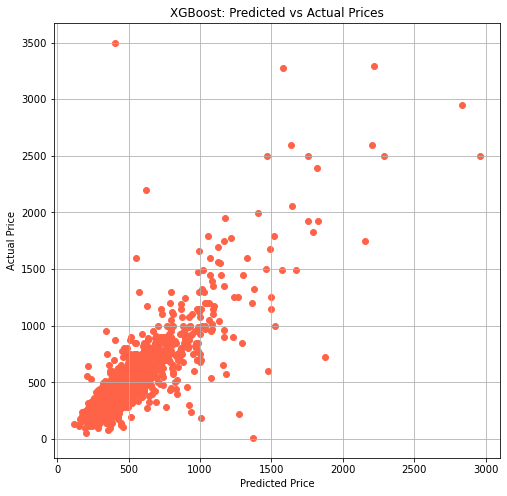

XGBoost Test RMSE: $160,891.60


In [8]:
# set up the test predictors
X_test = housing_test[predictors.columns]
y_test = housing_test['log_latestPrice']  # log-transformed target

# make predictions (still in log space)
y_pred = best_xgb.predict(X_test)

# Plot predicted vs actual (in price space)
plt.figure(figsize=(8, 8))
plt.scatter(np.exp(y_pred), np.exp(y_test), color='tomato')
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("XGBoost: Predicted vs Actual Prices")
plt.grid(True)
plt.show()

# Test MSE in dollar space
xgb_test_rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))
print(f'XGBoost Test RMSE: ${xgb_test_rmse * 1000:,.02f}')

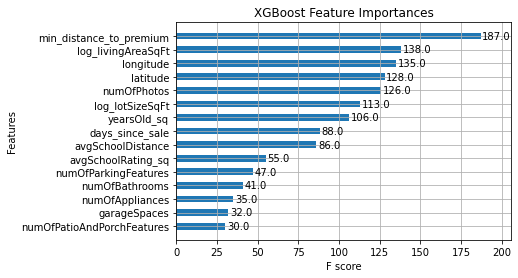

In [9]:
xgb.plot_importance(best_xgb, max_num_features=15, height=0.5)
plt.title("XGBoost Feature Importances")
plt.show()

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Extract top 15 features with F-score
booster = best_xgb.get_booster()
importance_dict = booster.get_score(importance_type='weight')

# Sort by F-score and get top 15
top15_features = sorted(importance_dict, key=importance_dict.get, reverse=True)[:15]
X_top15 = housing_binary_xg[top15_features]

X_vif = X_top15.copy()
X_vif['const'] = 1

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Drop the intercept row (constant term)
vif_df = vif_df[vif_df["Feature"] != "const"]

# Display
print(vif_df.sort_values(by="VIF", ascending=False))

                       Feature       VIF
1           log_livingAreaSqFt  4.105147
11              numOfBathrooms  2.977787
2                    longitude  2.755053
9           avgSchoolRating_sq  2.390979
3                     latitude  2.223487
13                garageSpaces  1.999657
6                  yearsOld_sq  1.910878
10        numOfParkingFeatures  1.870519
7              days_since_sale  1.805218
0      min_distance_to_premium  1.594034
14  numOfPatioAndPorchFeatures  1.587746
5              log_lotSizeSqFt  1.438351
4                  numOfPhotos  1.253580
8            avgSchoolDistance  1.174503
12             numOfAppliances  1.068869


In [21]:
# define the predictors and the target
predictors = housing_train.drop(columns = ['latestPrice','log_latestPrice'])
target = housing_train['latestPrice']

X_train = predictors
y_train = target

# define the regressor

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # loss function, ie. how it's optimizing
    random_state=123, # for reproducibility
    n_jobs=-1 # use all cores
)

param_grid = {
    'n_estimators': [100, 300], # number of boosting rounds (trees)
    'max_depth': [3, 6, 10], # max depth of trees
    'learning_rate': [0.1, 0.3], # learning rate (low is slow but accurate).  A learning rate is how much each tree or model iteration is allowed to change the final prediction
    'subsample': [0.7, 1.0], # what fraction of data each tree sees
    'colsample_bytree': [0.7, 1.0] # what fraction of features each tree sees
}

kfold = KFold(n_splits=5, shuffle=True, random_state=123)

# the grid search trains all combinations of the param_grid on every cv fold
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error', # higher is better, hence the sign switch
    n_jobs=-1,
    verbose=1,
    refit=True # finds the best fit and refits on the full training data
)

grid.fit(X_train, y_train) # fit it
best_xgb = grid.best_estimator_ # the final model is saved here


Fitting 5 folds for each of 48 candidates, totalling 240 fits


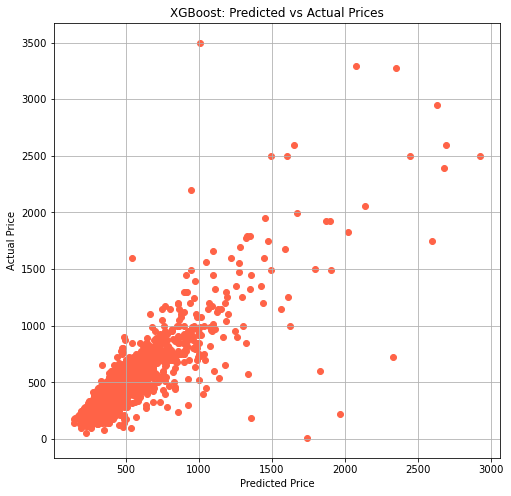

XGBoost Test RMSE: $160,196.62


In [22]:
# set up the test predictors
X_test = housing_test[predictors.columns]
y_test = housing_test['latestPrice']


y_pred = best_xgb.predict(X_test) # makes predictions on the test set

# Plot predicted vs actual - should be a straight line if it's perfect
plt.figure(figsize=(8, 8))
plt.scatter(y_pred, y_test, color='tomato')
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("XGBoost: Predicted vs Actual Prices")
plt.grid(True)
plt.show()

# Test MSE - out of sample MSE
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'XGBoost Test RMSE: ${xgb_test_rmse * 1000:,.02f}')



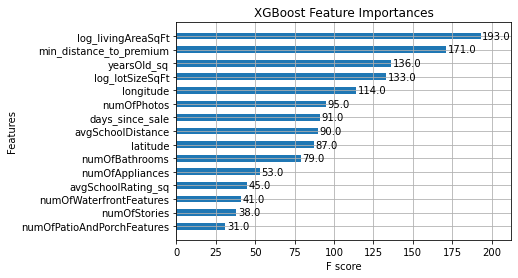

In [23]:
xgb.plot_importance(best_xgb, max_num_features=15, height=0.5)
plt.title("XGBoost Feature Importances")
plt.show()


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Extract top 15 features with F-score
booster = best_xgb.get_booster()
importance_dict = booster.get_score(importance_type='weight')

# Sort by F-score and get top 15
top15_features = sorted(importance_dict, key=importance_dict.get, reverse=True)[:15]
X_top15 = housing_binary_xg[top15_features]

X_vif = X_top15.copy()
X_vif['const'] = 1

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Drop the intercept row (constant term)
vif_df = vif_df[vif_df["Feature"] != "const"]

# Display
print(vif_df.sort_values(by="VIF", ascending=False))

                    Feature       VIF
0        log_livingAreaSqFt  4.196568
9            numOfBathrooms  3.393628
4                 longitude  2.746864
11       avgSchoolRating_sq  2.387687
8                  latitude  2.167471
2               yearsOld_sq  1.924123
13             numOfStories  1.805687
1   min_distance_to_premium  1.599710
3           log_lotSizeSqFt  1.507958
6           days_since_sale  1.282079
5               numOfPhotos  1.251535
14             garageSpaces  1.245420
7         avgSchoolDistance  1.171003
10          numOfAppliances  1.049060
12  numOfWaterfrontFeatures  1.008026


In [ ]:
#Remove zipcode features 


In [11]:

predictors = housing_train.drop(columns=['latestPrice', 'log_latestPrice', 'zipcode78702',
        'zipcode78703', 'zipcode78704', 'zipcode78705', 'zipcode78717',
        'zipcode78721', 'zipcode78722', 'zipcode78723', 'zipcode78724',
        'zipcode78725', 'zipcode78726', 'zipcode78727', 'zipcode78728',
        'zipcode78729', 'zipcode78730', 'zipcode78731', 'zipcode78732',
        'zipcode78733', 'zipcode78735', 'zipcode78736', 'zipcode78737',
        'zipcode78739', 'zipcode78741', 'zipcode78744', 'zipcode78745',
        'zipcode78746', 'zipcode78747', 'zipcode78748', 'zipcode78749',
        'zipcode78750', 'zipcode78751', 'zipcode78752', 'zipcode78753',
        'zipcode78754', 'zipcode78756', 'zipcode78757', 'zipcode78758',
        'zipcode78759'])
target = housing_train['log_latestPrice']  # log target now

X_train = predictors
y_train = target

# define the XGBoost regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # squared error loss for regression
    random_state=123,              # ensures reproducibility
    n_jobs=-1                      # use all available CPU cores
)

# hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 300],          # number of boosting rounds
    'max_depth': [3, 6, 10],             # depth of individual trees
    'learning_rate': [0.1, 0.3],         # step size shrinkage
    'subsample': [0.7, 1.0],             # fraction of samples for each tree
    'colsample_bytree': [0.7, 1.0]       # fraction of features for each tree
}

# cross-validation setup
kfold = KFold(n_splits=5, shuffle=True, random_state=123)

# grid search for best combination of parameters
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

# train models and find best
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits


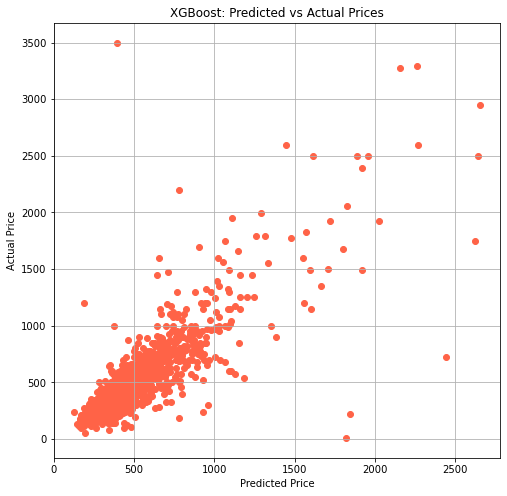

XGBoost Test RMSE: $167,066.50


In [12]:
# set up the test predictors
X_test = housing_test[predictors.columns]
y_test = housing_test['log_latestPrice']  # log-transformed target

# make predictions (still in log space)
y_pred = best_xgb.predict(X_test)

# Plot predicted vs actual (in price space)
plt.figure(figsize=(8, 8))
plt.scatter(np.exp(y_pred), np.exp(y_test), color='tomato')
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("XGBoost: Predicted vs Actual Prices")
plt.grid(True)
plt.show()

# Test MSE in dollar space
xgb_test_rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))
print(f'XGBoost Test RMSE: ${xgb_test_rmse * 1000:,.02f}')

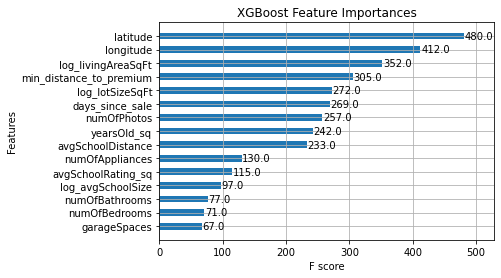

In [13]:
xgb.plot_importance(best_xgb, max_num_features=15, height=0.5)
plt.title("XGBoost Feature Importances")
plt.show()

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Extract top 15 features with F-score
booster = best_xgb.get_booster()
importance_dict = booster.get_score(importance_type='weight')

# Sort by F-score and get top 15
top15_features = sorted(importance_dict, key=importance_dict.get, reverse=True)[:15]
X_top15 = housing_binary_xg[top15_features]

X_vif = X_top15.copy()
X_vif['const'] = 1

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Drop the intercept row (constant term)
vif_df = vif_df[vif_df["Feature"] != "const"]

# Display
print(vif_df.sort_values(by="VIF", ascending=False))

                    Feature       VIF
2        log_livingAreaSqFt  4.878851
10       avgSchoolRating_sq  3.230734
12           numOfBathrooms  3.061423
1                 longitude  2.804305
0                  latitude  2.243485
13            numOfBedrooms  2.162637
7               yearsOld_sq  1.938472
11        log_avgSchoolSize  1.877777
3   min_distance_to_premium  1.701599
4           log_lotSizeSqFt  1.434434
5           days_since_sale  1.279971
6               numOfPhotos  1.250125
14             garageSpaces  1.245889
8         avgSchoolDistance  1.177188
9           numOfAppliances  1.048116
